# SVM training on the Data
# Paramita July 7th, 2026

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import hmean, median_abs_deviation, iqr, skew, kurtosis
import os

# 1. Mapping PAMAP2 raw .dat columns to the common naming convention
# PAMAP2 standard indices: HR=2. Hand IMU=4-20, Chest IMU=21-37, Ankle IMU=38-54
sensor_dict = {
    'heart_rate': [2],
    'hand_acc16': [4, 5, 6], 'hand_gyro': [10, 11, 12],
    'chest_acc16': [21, 22, 23], 'chest_gyro': [27, 28, 29],
    'ankle_acc16': [38, 39, 40], 'ankle_gyro': [44, 45, 46]
}

def calc_stats(array):
    """Calculates the 13 required statistics for a given 1D array."""
    # Drop NaNs for statistical calculations
    a = array[~np.isnan(array)]
    
    if len(a) == 0:
        return np.full(13, np.nan)
        
    return [
        np.mean(a),
        hmean(np.abs(a) + 1e-6), # Abs and epsilon to prevent harmonic mean crash on negatives/zeros
        np.std(a),
        np.max(a),
        np.min(a),
        np.median(a),
        np.ptp(a), # Peak-to-peak (p2p)
        median_abs_deviation(a), # mad
        iqr(a),
        np.sum(np.abs(a)), # sum_abs
        np.mean(a**2), # mean_energy
        skew(a),
        kurtosis(a)
    ]

def calc_corr(a, b):
    """Calculates Pearson correlation between two arrays."""
    mask = ~np.isnan(a) & ~np.isnan(b)
    if np.sum(mask) < 2:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

In [3]:
# --- Configuration ---
# UPDATE THESE PATHS
base_path = '/Users/dasgupta/Erdos_project/erdos_env/pamap2+physical+activity+monitoring/PAMAP2_Dataset/Protocol/'

map_path = '/Users/dasgupta/Downloads/filtered_activities.csv'
# Load the map
activities_map = pd.read_csv(map_path)

# Initialize storage
all_features = []
cached_subject = None
raw_data = None

print("Starting feature extraction...")

# Loop through every row in the filtered activities map
for index, row in activities_map.iterrows():
    subject_id = int(row['subject_id'])
    act_id = int(row['activity_id'])
    n1, n2 = int(row['n1']), int(row['n2'])
    
    # Load .dat file only if we moved to a new subject
    if subject_id != cached_subject:
        file_name = f'subject{subject_id}.dat'
        print(f"Loading {file_name}...")
        raw_data = pd.read_csv(os.path.join(base_path, file_name), sep=r'\s+', header=None).values
        cached_subject = subject_id
        
    # Slice the raw data using n1 and n2
    window = raw_data[n1:n2]
    
    # Dictionary to hold this row's calculated features
    row_features = {
        'activity_id': act_id,
        'subject_id': subject_id,
        'interval_id': index # Using loop index as interval_id for GroupShuffleSplit
    }
    
    # 1. Heart Rate Features
    hr_stats = calc_stats(window[:, sensor_dict['heart_rate'][0]])
    for idx, stat_name in enumerate(['mean', 'hmean', 'std', 'max', 'min', 'median', 'p2p', 'mad', 'iqr', 'sum_abs', 'mean_energy', 'skew', 'kurtosis']):
        row_features[f"heart_rate_{stat_name}"] = hr_stats[idx]
        
    # 2. IMU Features (Acc & Gyro for Hand, Chest, Ankle)
    for device in ['hand', 'chest', 'ankle']:
        for sensor in ['acc16', 'gyro']:
            cols = sensor_dict[f"{device}_{sensor}"]
            
            x, y, z = window[:, cols[0]], window[:, cols[1]], window[:, cols[2]]
            amp = np.sqrt(x**2 + y**2 + z**2) # Calculate amplitude
            
            axes_data = {'x': x, 'y': y, 'z': z, 'amp': amp}
            
            # Calculate the 13 stats for x, y, z, and amp
            for axis_name, axis_array in axes_data.items():
                stats = calc_stats(axis_array)
                for idx, stat_name in enumerate(['mean', 'hmean', 'std', 'max', 'min', 'median', 'p2p', 'mad', 'iqr', 'sum_abs', 'mean_energy', 'skew', 'kurtosis']):
                    row_features[f"{device}_{sensor}_{axis_name}_{stat_name}"] = stats[idx]
            
            # Calculate Correlations (xy, xz, yz)
            row_features[f"{device}_{sensor}_corr_xy"] = calc_corr(x, y)
            row_features[f"{device}_{sensor}_corr_xz"] = calc_corr(x, z)
            row_features[f"{device}_{sensor}_corr_yz"] = calc_corr(y, z)

    all_features.append(row_features)

print("Extraction complete. Saving features.csv...")

# Convert to DataFrame and save
features_df = pd.DataFrame(all_features)
features_df.to_csv('features.csv', index=False)

print(f"Success! features.csv created with shape: {features_df.shape}")

Starting feature extraction...
Loading subject101.dat...
Loading subject102.dat...
Loading subject103.dat...
Loading subject104.dat...
Loading subject105.dat...
Loading subject106.dat...
Loading subject107.dat...
Loading subject108.dat...
Extraction complete. Saving features.csv...


OSError: Cannot save file into a non-existent directory: '../ML_pipeline'

In [7]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

# Load the newly generated features
full_df = pd.read_csv('features.csv')
print(f"Data loaded successfully! Shape: {full_df.shape}")

Data loaded successfully! Shape: (105, 346)


In [9]:
device_list = ['hand', 'chest', 'ankle']
axes_list = ['x', 'y', 'z', 'amp']
sensor_list = ['acc16', 'gyro']
stat_list = ['mean', 'hmean', 'std', 'max', 'min', 'median', 'p2p', 
             'mad', 'iqr', 'sum_abs', 'mean_energy', 'skew', 'kurtosis']

feature_list = []

# Heart Rate Features
for stat in stat_list:
    feature_list.append('heart_rate_'+stat)

# IMU Features
for device in device_list:
    for sensor in sensor_list:
        for axis in axes_list:
            for stat in stat_list:
                label = '_'.join([device,sensor,axis,stat])
                feature_list.append(label)
        
        # Correlation Features
        for pair in ['xy','xz','yz']:
            label = '_'.join([device,sensor,'corr',pair])
            
print(f"Feature list rebuilt. Total features mapped: {len(feature_list)}")

Feature list rebuilt. Total features mapped: 325


In [11]:
# Define X (features), y (target), and groups (window intervals)
X = full_df[feature_list]
y = full_df['activity_id']
groups = full_df['interval_id']

print(f"X shape: {X.shape}")
print("\nClass counts (Activity IDs):")
print(y.value_counts().sort_index())

# Split the data 
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTraining set size: {X_train.shape[0]} windows")
print(f"Test set size: {X_test.shape[0]} windows")

X shape: (105, 325)

Class counts (Activity IDs):
activity_id
1      8
2      8
3      8
4      8
5      6
6      7
7      7
12    16
13    17
16     8
17     8
24     4
Name: count, dtype: int64

Training set size: 84 windows
Test set size: 21 windows


In [13]:
from sklearn.impute import SimpleImputer

# Define the SVM training and evaluation pipeline
def run_SVM(C=1.0, kernel='rbf'):
    svm_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")), 
        ("scaler", StandardScaler()),                
        ("SVM", SVC(C=C, kernel=kernel, random_state=42)),
    ])

    # Train the model
    svm_pipeline.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = svm_pipeline.predict(X_test)

    # Generate Confusion Matrix
    labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels_sorted),
        index=[f"true_{lbl}" for lbl in labels_sorted],
        columns=[f"pred_{lbl}" for lbl in labels_sorted],
    )

    # Generate Metrics
    acc_score = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    return acc_score, report, cm
    
print("SVM training pipeline is ready and NaN-proof!")

SVM training pipeline is ready and NaN-proof!


In [15]:
# Hyperparameters to test
C_vals = [0.1, 1, 10]
kernel_vals = ['linear', 'rbf']

acc_dict = {}
report_dict = {}
cm_dict = {}

# Run the grid search
for kernel in kernel_vals:
    for C in C_vals:
        print(f"Training SVM: kernel={kernel}, C={C}...")
        acc_score, report, cm = run_SVM(C=C, kernel=kernel)

        label = f"{kernel}-{C}"
        acc_dict[label] = acc_score
        report_dict[label] = report
        cm_dict[label] = cm

print("\n" + "="*40)
print("--- FINAL ACCURACIES ---")
for k, v in acc_dict.items():
    print(f"{k}: {v:.4f}")

print("\n" + "="*40)
print("--- BASELINE REPORT (RBF Kernel, C=1) ---")
print(report_dict['rbf-1'])

print("\n" + "="*40)
print("--- BASELINE CONFUSION MATRIX (RBF Kernel, C=1) ---")
print(cm_dict['rbf-1'])

Training SVM: kernel=linear, C=0.1...
Training SVM: kernel=linear, C=1...
Training SVM: kernel=linear, C=10...
Training SVM: kernel=rbf, C=0.1...
Training SVM: kernel=rbf, C=1...
Training SVM: kernel=rbf, C=10...

--- FINAL ACCURACIES ---
linear-0.1: 0.8571
linear-1: 0.8571
linear-10: 0.8571
rbf-0.1: 0.0476
rbf-1: 0.7143
rbf-10: 0.8571

--- BASELINE REPORT (RBF Kernel, C=1) ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         0
           3       1.00      0.33      0.50         3
           5       1.00      0.33      0.50         3
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
          12       0.50      1.00      0.67         1
          13       1.00      1.00      1.00         4
          16       1.00      1.00      1.00         2
          17       0.67      1.00      0.80         2
          24       0.00 

In [17]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score

# 1. Map PAMAP2 IDs to actual activity names for readability
activity_names = {
    1: 'Lying', 2: 'Sitting', 3: 'Standing', 4: 'Walking', 
    5: 'Running', 6: 'Cycling', 7: 'Nordic Walking', 
    12: 'Ascending Stairs', 13: 'Descending Stairs', 
    16: 'Vacuuming', 17: 'Ironing', 24: 'Rope Jumping'
}

# 2. Setup the Cross-Validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Define BOTH pipelines
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("SVM", SVC(C=1.0, kernel='linear', random_state=42))
])

knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("KNN", KNeighborsClassifier(n_neighbors=5)) # Charlie's default KNN
])

print("Running 5-Fold CV for SVM...")
y_pred_svm = cross_val_predict(svm_pipeline, X, y, cv=cv)

print("Running 5-Fold CV for KNN (Charlie's Model)...")
y_pred_knn = cross_val_predict(knn_pipeline, X, y, cv=cv)

# 4. Generate reports as dictionaries so we can extract the math
report_svm = classification_report(y, y_pred_svm, zero_division=0, output_dict=True)
report_knn = classification_report(y, y_pred_knn, zero_division=0, output_dict=True)

# 5. Build the comparison table
comparison_data = []

for act_id in np.unique(y):
    str_id = str(act_id)
    name = activity_names.get(act_id, f"Activity {act_id}")
    
    svm_f1 = report_svm[str_id]['f1-score']
    knn_f1 = report_knn[str_id]['f1-score']
    
    # Determine which one worked better for this specific class
    if svm_f1 > knn_f1:
        winner = 'SVM'
    elif knn_f1 > svm_f1:
        winner = 'KNN'
    else:
        winner = 'Tie'
        
    comparison_data.append({
        'ID': act_id,
        'Activity Name': name,
        'SVM F1': f"{svm_f1:.3f}",
        'KNN F1': f"{knn_f1:.3f}",
        'Winner': winner
    })

# 6. Display the results
comp_df = pd.DataFrame(comparison_data)

print("\n" + "="*55)
print("--- SVM vs. KNN: CLASS-BY-CLASS COMPARISON ---")
print("="*55)
print(comp_df.to_string(index=False))

# Overall scores
print("\n" + "="*55)
print(f"Overall SVM Accuracy: {accuracy_score(y, y_pred_svm):.3f}")
print(f"Overall KNN Accuracy: {accuracy_score(y, y_pred_knn):.3f}")

Running 5-Fold CV for SVM...
Running 5-Fold CV for KNN (Charlie's Model)...


/opt/homebrew/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



--- SVM vs. KNN: CLASS-BY-CLASS COMPARISON ---
 ID     Activity Name SVM F1 KNN F1 Winner
  1             Lying  1.000  1.000    Tie
  2           Sitting  0.933  0.857    SVM
  3          Standing  0.875  0.875    Tie
  4           Walking  1.000  0.941    SVM
  5           Running  0.800  0.769    SVM
  6           Cycling  1.000  1.000    Tie
  7    Nordic Walking  1.000  0.923    SVM
 12  Ascending Stairs  1.000  0.941    SVM
 13 Descending Stairs  0.971  0.971    Tie
 16         Vacuuming  0.889  1.000    KNN
 17           Ironing  0.941  0.889    SVM
 24      Rope Jumping  0.857  0.000    SVM

Overall SVM Accuracy: 0.952
Overall KNN Accuracy: 0.914


Running 5-Fold GroupKFold CV for SVM...


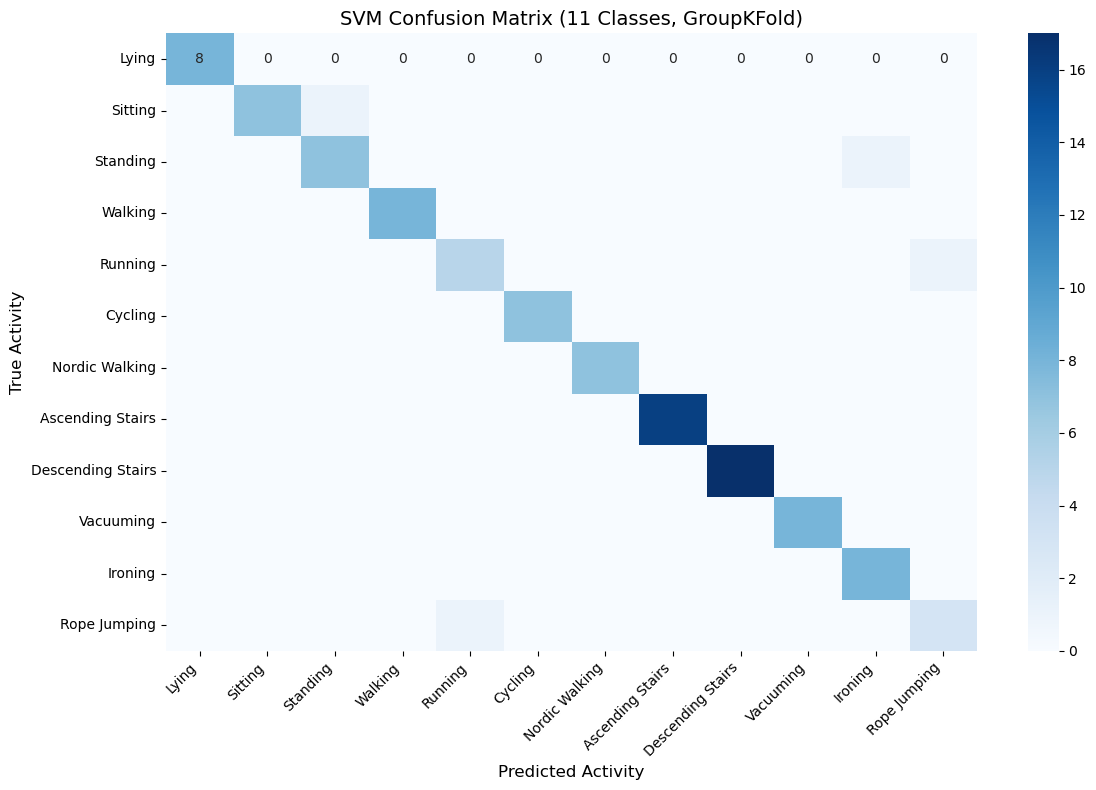


Overall SVM Accuracy (GroupKFold): 0.962


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix

# 1. GroupKFold 
gkf = GroupKFold(n_splits=5)
groups = full_df['interval_id'] # Ensures data from the same time window stays together

print("Running 5-Fold GroupKFold CV for SVM...")
# Pass the groups parameter into cross_val_predict
y_pred_svm_gkf = cross_val_predict(svm_pipeline, X, y, cv=gkf, groups=groups)

# 2. Generate the Confusion Matrix Plot

# Get the unique labels actually present in the data to label the axes correctly
labels_present = np.unique(y)
target_names = [activity_names[act_id] for act_id in labels_present]

cm = confusion_matrix(y, y_pred_svm_gkf, labels=labels_present)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)

plt.title('SVM Confusion Matrix (11 Classes, GroupKFold)', fontsize=14)
plt.ylabel('True Activity', fontsize=12)
plt.xlabel('Predicted Activity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot as an image file (we might consider adding to the final presentation)
plt.savefig('svm_confusion_matrix.png', dpi=300)
plt.show()

# 3. Print the updated overall accuracy
print(f"\nOverall SVM Accuracy (GroupKFold): {accuracy_score(y, y_pred_svm_gkf):.3f}")